<h1 align="left"><u><b>Projet de Machine Learning : Accident de voiture en France en 2021</u></h1>

<h2 align="left"><b>ANTONI Jade et DESTINE Hugo</h1>


---

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss, accuracy_score, classification_report

df = pd.read_csv('./train_data_accidents.csv')

---

# **1. Découverte des données**

Voici une première analyse afin d'afficher la répartition de notre objectif (`grav`) :

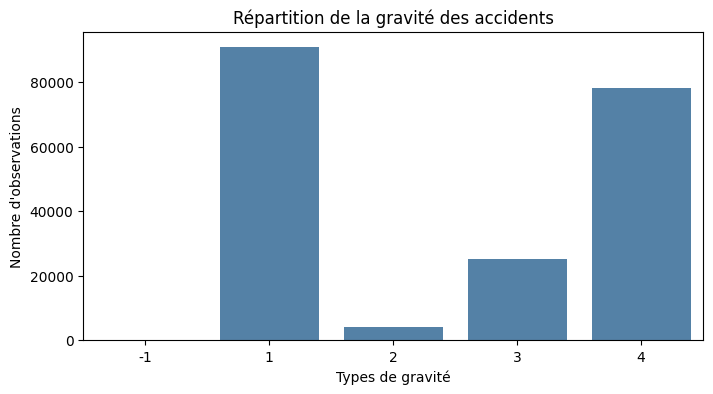

In [2]:
plt.figure(figsize=(8, 4))
sns.countplot(x='grav', data=df, color='steelblue')
plt.title('Répartition de la gravité des accidents')
plt.xlabel('Types de gravité')
plt.ylabel('Nombre d\'observations')
plt.show()

---

# **2. Nettoyage des données**

Certaines données ne nous permettent pas de prédire quoi que ce soit, ou sont inexploitables par le réseau de neurones, nous devons donc les supprimer :

In [3]:
df.drop(df.index[df['grav'] == -1], axis = 0, inplace = True)
df.drop(df.index[df['sexe'] == -1], axis = 0, inplace = True)
df.drop(df.index[df['place'] == -1], axis = 0, inplace = True)

**Remarque :** Nous avons fait le choix de supprimer tous les "-1" (non renseigné) de la gravité puisqu'il s'agit de notre objectif.
Nous voulions faire en sorte que le modèle soit toujours capable de prédire une gravité; mais nous aurions pu faire le choix de les conserver afin que le modèle puisse choisir que certaines situations ne permettent pas de renseigner une gravité précise.

Dans un premier temps, nous constatons que certaines valeurs de colonnes sont inutilisées / très peu représentées, nous avons donc décidés de les regrouper pour réduire la dimension et limiter l'overfitting.

<Axes: >

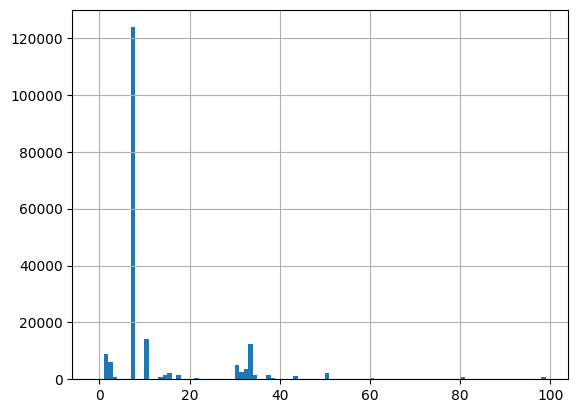

In [4]:
df['catv'].hist(bins = 100)

---

## **2.1. Parsing**

Pour remplacer la colonne "hrmn", nous avons décidé d'en extraire seulement l'heure de la journée (qui nous paraît plus pertinente), nous l'avons donc parsé comme ceci :

In [ ]:
df['heure'] = df['hrmn'].str.split(':').str[0]

De même avec l'âge des individus, plus parlant que simplement leurs années de naissance :

In [ ]:
df = df.dropna(subset=['an_nais'])
df['age'] = 2021 - df['an_nais']

---

## **2.2. Regroupement**

In [ ]:
# 1. Simplification des catégories de véhicules :
groupes_catv = {
    1: [1, 50, 60, 80], # vélos, hoverboard etc.
    2: [2, 30, 4, 5, 6, 31, 32, 33, 34, 41, 42, 43, 35, 36], # 2 roues / 3 roues motorisés et quads
    4: [3, 7, 8, 9, 10, 11, 12], # véhicules légers
    5: [13, 14, 15, 16, 17, 18, 19, 37, 38, 39, 40], # poids lourd
    6: [20, 21, 0, 99] # autres (tracteurs etc.)
}
for key, values in groupes_catv.items():
    df["catv"] = df["catv"].replace(values, key)


# 2. Places dans le véhicule :
groupes_place = {
    2 : [2, 6], # passagers avant
    3 : [7, 8, 9], # passagers arrières
    4 : [3, 4, 5] # siègles supplémentaires
}
for key, values in groupes_place.items():
    df["place"] = df["place"].replace(values, key)


# 3. Valeurs indéterminés (-1 et 0) en un seul groupe :
groupes_undefined = {
    0 : [-1, 0]
}
for key, values in groupes_undefined.items():
    df["trajet"] = df["trajet"].replace(values, key)
    df["obs"] = df["obs"].replace(values, key)
    df['choc'] = df['choc'].replace(values, key)


# 4. Obstacles fixes percutés :
groupes_obs = {
    3 : [3, 4, 5]
}
for key, values in groupes_obs.items():
    df["obs"] = df["obs"].replace(values, key)


# 5. Obstacles mobiles :
groupes_obsm = {
    2 : [2, 4],
    5 : [5, 6]
}
for key, values in groupes_obsm.items():
  df["obsm"] = df["obsm"].replace(values, key)


# 6. Point de choc initial :
groupe_choc = {
    1 : [1, 2, 3], # choc avant
    4 : [4, 5, 6]  # choc arrière
}
for key, values in groupe_choc.items():
  df["choc"] = df["choc"].replace(values, key)


# 7. Manoeuvre du véhicule
groupes_manv = {
    11 : [11, 13, 15, 17], # changement de file, ou virage, à gauche
    12 : [12, 14, 16, 18]  # changement de file, ou virage, à droite
}
for key, values in groupes_manv.items():
  df["manv"].replace(values, key)


# 8. Catégorie de route :
groupes_catr = {
    5 : [5, 6, 9]
}
for key, values in groupes_catr.items():
  df["catr"].replace(values, key)


# 9. Etat de la surface :
groupes_surf = {
    3 : [3, 4, 5, 6, 7, 8, 9]
}
for key, values in groupes_surf.items():
  df["surf"].replace(values, key)


# 10. Infrastructures spéciales :
groupes_infra = {
    9 : [4, 6, 7, 8, 9]
}
for key, values in groupes_infra.items():
  df["infra"].replace(values, key)


In [ ]:
df['is_protected'] = df[['secu1', 'secu2', 'secu3']].isin([1, 2, 3, 5, 6, 7]).any(axis=1).astype(int)
df.drop(columns=['jour', 'occutc', 'lat', 'long', 'hrmn', 'an_nais', 'secu1','secu2', 'secu3', 'vosp'], inplace=True)

## **2.3. Suppression des NaN, données non renseignées etc.**

In [ ]:
df.drop(df.index[(df['obsm'] == 1) & (df['locp'] == -1)], axis = 0, inplace = True)
df.drop(df.index[(df['obsm'] == 1) & (df['locp'] == 0)], axis = 0, inplace = True)
df.drop(df.index[(df['catv'] == -1)], axis = 0, inplace = True)

## **2.4. Normalisation**

In [ ]:
colonnes_num = ['age', 'heure', 'mois']
scaler = StandardScaler()
df[colonnes_num] = scaler.fit_transform(df[colonnes_num])
#df.describe()

## **2.5. Séparation données / labels**

In [ ]:
"""
labels = df['grav']
labels = labels - 1
df = df.drop(columns=["grav"])
"""

---

# **3. Création des dummies**

Afin d'empêcher les modèles de faire des corrélations entre certaines valeurs, nous avons utilisé le One-Hot-Encoding sur la majorité des features de notre jeu de données.
Pour ça, nous utilisons `pandas.get_dummies`, trouvé dans la documentation.

In [ ]:
"""
df = pd.get_dummies(df, columns=['place', 'catu', 'sexe', 'trajet', 'locp',
                                 'catv', 'obs', 'obsm', 'choc', 'manv','lum', 'agg', 'int', 'atm', 'col',
                                 'catr', 'circ', 'prof','plan', 'surf', 'infra', 'situ'])

print(len(df.columns))
"""

---

# **4. Variance**

In [ ]:
variances = df.var(numeric_only=True)
print(variances.sort_values())

---

# **5. Création du modèle, entraînement et résultats**

In [ ]:
# création des jeux d'entraînement et de test
# x_train, x_test, y_train, y_test = train_test_split(df, labels, test_size=0.25, train_size=0.75)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import pandas as pd

# 1. On sépare X et y avant toute transformation
X = df.drop('grav', axis=1)
y = df['grav']
y = y - 1

# 2. Split Train/Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Liste des colonnes à encoder
cat_cols = ['place', 'catu', 'sexe', 'trajet', 'locp', 'catv', 'obs',
            'obsm', 'choc', 'manv', 'lum', 'agg', 'int', 'atm', 'col',
            'catr', 'circ', 'prof', 'plan', 'surf', 'infra', 'situ']

# 4. Configuration du OneHotEncoder
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# On fit uniquement sur le train
X_train_ohe = ohe.fit_transform(X_train[cat_cols])
X_test_ohe = ohe.transform(X_test[cat_cols])

# 5. Création des noms de colonnes pour retrouver la clarté de get_dummies
ohe_columns = ohe.get_feature_names_out(cat_cols)

# 6. Recomposition des DataFrames
X_train_final = pd.concat([
    X_train.drop(columns=cat_cols).reset_index(drop=True),
    pd.DataFrame(X_train_ohe, columns=ohe_columns)
], axis=1)

X_test_final = pd.concat([
    X_test.drop(columns=cat_cols).reset_index(drop=True),
    pd.DataFrame(X_test_ohe, columns=ohe_columns)
], axis=1)

# 7. Application du StandardScaler sur X_train_final
scaler = StandardScaler()
x_train = scaler.fit_transform(X_train_final)
x_test = scaler.transform(X_test_final)

print(f"Nombre de colonnes initial : {X.shape[1]}")
print(f"Nombre de colonnes générées par l'OHE : {len(ohe_columns)}")
print(f"Nombre de colonnes final : {X_train_final.shape[1]}")

## **5.1. Standardisation finale des données et configuration**

In [ ]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train) # moyenne/écart-type sur le train
x_test_scaled = scaler.transform(x_test)  # même paramètres sur le test

max_iters = [50, 100, 200]
c_values = [0.01, 1, 10]
solvers = []

results = []

print("Lancement du test comparatif...")

# BOUCLE D'ENTRAINEMENT ET D'EVALUATION :
for c in c_values:
  acc_list = []
  loss_list = []

  for m_iter in max_iters:
    # Initialisation du modèle :
    model = LogisticRegression(
        max_iter=m_iter,
        C=c,
        solver='newton-cg',
        class_weight='balanced',
        random_state=42
    )

    model.fit(x_train_scaled, y_train)

    acc = model.score(x_test_scaled, y_test)
    probs = model.predict_proba(x_test_scaled)
    loss = log_loss(y_test, probs)

    acc_list.append(acc)
    loss_list.append(loss)

    print(f"C={c} | Iterations = {m_iter} -> Accuracy: {acc:.4f} | Loss: {loss:.4f}")

  results.append({
      'label': f"(C={c})",
      'acc': acc_list,
      'loss': loss_list
  })


# Visualisation des performances :
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for res in results:
    ax1.plot(max_iters, res['acc'], marker='o', label=res['label'])
    ax2.plot(max_iters, res['loss'], marker='s', label=res['label'])

ax1.set_title("Précision (Accuracy)")
ax1.set_xlabel("Nombre d'itérations")
ax1.set_ylabel("Score")
ax1.legend()
ax1.grid(True)

ax2.set_title("Perte (Log Loss)")
ax2.set_xlabel("Nombre d'itérations")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## **5.2. Modèle d'arbre de décision**

In [ ]:
depths = [50, 100]
min_samples = [50, 100, 1000]

results = []

for ms in min_samples:
  acc_list = []
  loss_list = []

  for d in depths:
    # Initialisation de l'arbre de décision :
    model = DecisionTreeClassifier(
        criterion='gini',
        max_depth=d,
        min_samples_split=ms,
        class_weight='balanced',
        random_state=42
    )
    model.fit(x_train, y_train)

    y_prob = model.predict_proba(x_test)
    y_pred = model.predict(x_test)

    loss = log_loss(y_test, y_prob)
    accuracy = accuracy_score(y_test, y_pred)

    acc_list.append(accuracy)
    loss_list.append(loss)
    print(f"Profondeur: {d} | Samples: {ms} | Score: {accuracy:.2%} | Loss: {loss}")

  results.append({
      'label': f"min_samples={ms}",
      'acc': acc_list,
      'loss': loss_list
  })


# Visualisation des résultats
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for res in results:
    ax1.plot(depths, res['acc'], marker='o', label=res['label'])
    ax2.plot(depths, res['loss'], marker='s', label=res['label'])

ax1.set_title("Précision (Accuracy)")
ax1.set_xlabel("Profondeur")
ax1.set_ylabel("Score")
ax1.legend()
ax1.grid(True)

ax2.set_title("Perte (Log Loss)")
ax2.set_xlabel("Nombre d'itérations")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

On voit que les valeurs commencent à stagner autour d'une profondeur de 50 \
On constate qu'augmenter le nombre de min_samples ne fait pas tout, car la loss est très faible, mais l'accuracy aussi

## **5.3. Modèle de forêt aléatoire**

In [ ]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, log_loss

nb_arbres = [50, 100, 200]
profondeurs = [20, 100]
results = []

for d in profondeurs:
  acc_par_step = []
  loss_par_step = []

  for n in nb_arbres:
    # Initialisation de la RandomForest :
    model = RandomForestClassifier(
        n_estimators=n,
        max_depth=d,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )

    model.fit(x_train, y_train)

    preds = model.predict(x_test)
    probs = model.predict_proba(x_test)

    loss = log_loss(y_test, probs)
    accuracy = accuracy_score(y_test, preds)

    label_d = d if d is not None else "Max"
    print(f"Profondeur: {label_d} | Arbres: {n} | Score: {accuracy:.2%} | Loss: {loss:.4}")

    acc_par_step.append(accuracy)
    loss_par_step.append(loss)

  results.append({'depth': d, 'acc': acc_par_step, 'loss': loss_par_step})


# Visualisation des résultats :
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

for res in results:
    nom = f"Profondeur {res['depth']}"
    ax1.plot(nb_arbres, res['acc'], '-o', label=nom)
    ax2.plot(nb_arbres, res['loss'], '-s', label=nom)

ax1.set_title("Précision (Accuracy)")
ax1.legend()
ax2.set_title("Erreur (Log Loss)")
ax2.legend()
plt.show()

On voit ici que les loss et accuracy stagnent à partir d'une profondeur de 100.
On remarque aussi que le nombre d'arbres utilisés améliore légèrement le résultat de nos tests

## **5.4. Modèle de réseau de neurones**

In [ ]:
# CREATION DU MODELE
# Nous avons utiliser une structure en "pyramide" pour nos couches :
model = tf.keras.models.Sequential([
    tf.keras.Input(shape=(x_train.shape[1],)),
    tf.keras.layers.Dense(500, 'relu'),
    tf.keras.layers.Dense(1000, 'relu'),
    tf.keras.layers.Dense(500, 'relu'),
    tf.keras.layers.Dense(100, 'relu'),
    tf.keras.layers.Dense(10, 'relu'),
    tf.keras.layers.Dense(4, 'softmax'),
])

model.compile(
    optimizer = 'adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

model.summary()

# Entrainement du modèle :
history = model.fit(x_train, y_train, epochs = 8, validation_data = (x_test, y_test))

# Evaluation finale sur l'ensemble de test :
model.evaluate(x_test, y_test, verbose=2)


In [ ]:
# VISUALISATION DES PERFORMNANCES

# Graph 1 : évolution de l'accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['loss'], label='Train Loss')
plt.title('Évolution de la précision')
plt.legend()

# Graph 2 : évolution de la loss
plt.subplot(1, 2, 1)
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Évolution de l\'erreur')
plt.legend()
plt.show()

### Avec regroupements (160 colonnes) :
[Loss, Accuracy]

LogisticRegression (lbfgs/newton-cg c=0.01) : [1.17, 0.44]\
DecisionTreeClassifier (Profondeur 50-100, min_samples 50-1000) :  [2.73-1.20,0.44-0.47]\
RandomForestClassifier (Profondeur 20-100, Nombre d'arbres 50-200) : [0.95-0.84, 0.46-0.63] \
Réseau de neurones (8 epochs) : [0.91, 0.57]

Avec nos colonnes et optimisation actuelles, tous les modèles finissent par faire de l'overfitting (haute accuracy / faible loss en entraînement, accuracy moyenne / loss moyenne en test)